In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import sys
sys.path.append('../')
from neural_net import NeuralNet
import examples.mushrooms as shroom
import graphics

In [2]:
mnist = fetch_openml('Fashion-MNIST', as_frame=False) #type:ignore
X, y = mnist.data, mnist.target # type:ignore
X = np.array(X)
y = np.astype(y, int)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [4]:
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [57]:
from layers.dense import Dense
from layers.input import Input

neural_net = NeuralNet([(Input, 28**2), (Dense, 128), (Dense, 10)], learning_rate=0.001, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")

neural_net.layers[-1].activation_method="softmax"
epochs = 10
losses, y_pred = neural_net.train(X_train, y_train, epochs, 64, validate=(X_test, y_test), binary=True)

EPOCH: 1    LOSS: 0.0538354    LOSS CHANGE: 0    TEST ACCURACY: 0.8159    TEST ACCURACY CHANGE 0.8159    TIME: 0.98 s
EPOCH: 2    LOSS: 0.040265    LOSS CHANGE: -0.01357    TEST ACCURACY: 0.8394    TEST ACCURACY CHANGE 0.0235    TIME: 1 s
EPOCH: 3    LOSS: 0.0361121    LOSS CHANGE: -0.004153    TEST ACCURACY: 0.8476    TEST ACCURACY CHANGE 0.008143    TIME: 1 s
EPOCH: 4    LOSS: 0.0335875    LOSS CHANGE: -0.002525    TEST ACCURACY: 0.8573    TEST ACCURACY CHANGE 0.009714    TIME: 1 s
EPOCH: 5    LOSS: 0.0316277    LOSS CHANGE: -0.00196    TEST ACCURACY: 0.862    TEST ACCURACY CHANGE 0.004714    TIME: 0.9 s
EPOCH: 6    LOSS: 0.0299687    LOSS CHANGE: -0.001659    TEST ACCURACY: 0.8412    TEST ACCURACY CHANGE -0.02079    TIME: 1 s
EPOCH: 7    LOSS: 0.0287059    LOSS CHANGE: -0.001263    TEST ACCURACY: 0.8704    TEST ACCURACY CHANGE 0.02914    TIME: 1 s
EPOCH: 8    LOSS: 0.0275407    LOSS CHANGE: -0.001165    TEST ACCURACY: 0.8694    TEST ACCURACY CHANGE -0.001    TIME: 1 s
EPOCH: 9    LO

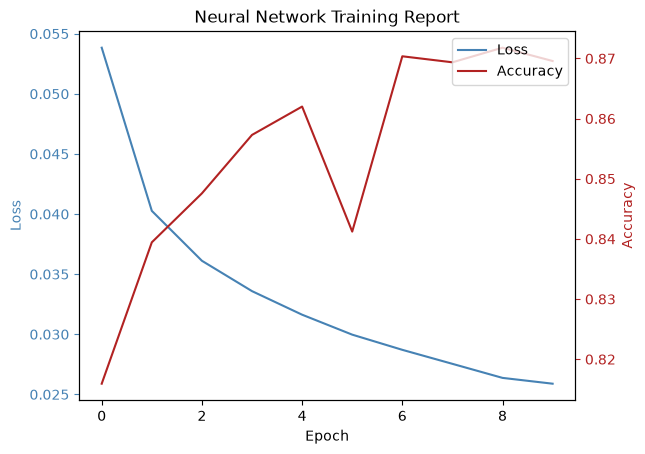

In [58]:
graphics.plot_report(neural_net)

In [59]:
from sklearn.metrics import accuracy_score

labels = ["T-shirt", "Trousers", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

y_pred = neural_net.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(f"Accuracy: {accuracy_score(y_pred, y_test)}")

Accuracy: 0.8695714285714286


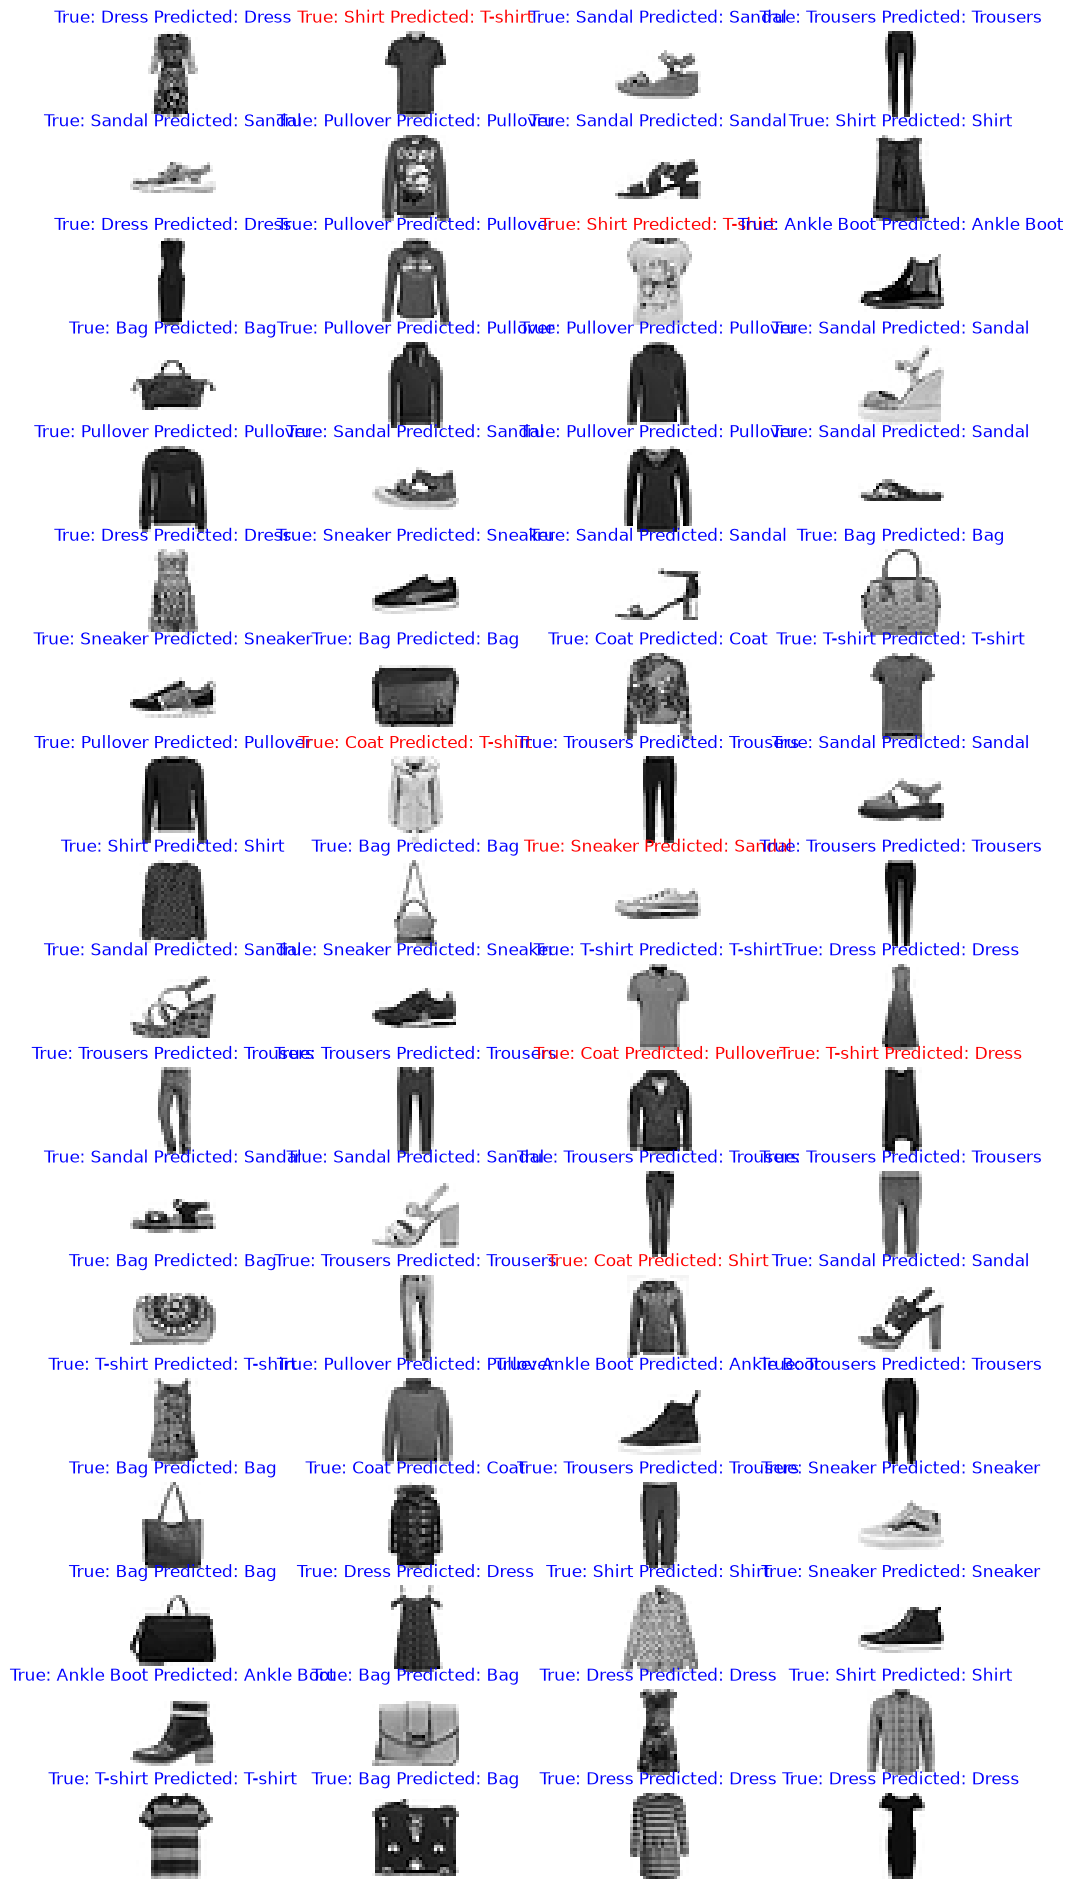

In [60]:
def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

k = 18
items_to_display = 4 * k

rows = k
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(12, 24))

for i in range(items_to_display):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i, labels[y_test.argmax(axis=1)[i]], labels[y_pred.argmax(axis=1)[i]])
    #print(f"Prediction: {y_pred.argmax(axis=1)[i]}")